# Nhóm 03 — Phân đoạn tín hiệu thành tiếng nói và khoảng lặng

**Sinh viên: Võ Thanh Quân**  
**Thuật toán riêng: Binary Search**

Notebook chứa mã và kết quả thực thi sẵn. Mở để đọc kết quả không cần WAV. Để chạy lại, cung cấp dữ liệu ngoài notebook và chỉnh DATA_ROOT. Không nộp WAV/LAB cùng file này.

Khung 25 ms, bước dịch 10 ms, Silence tối thiểu 200 ms. LAB training dùng để hiệu chỉnh theo BT1; LAB test chỉ đánh giá và vẽ biên chuẩn.

## 1. Thư viện và cấu hình

Chỉ dùng NumPy và thư viện chuẩn để xử lý tín hiệu. Matplotlib/IPython phục vụ vẽ và lưu kết quả hiển thị trong notebook.

In [1]:
from __future__ import annotations

from dataclasses import dataclass, asdict, replace
from pathlib import Path
import json
import math
import wave

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from matplotlib_inline.backend_inline import set_matplotlib_formats

# Hiển thị PNG trực tiếp và lưu trong output của notebook, không mở cửa sổ GUI.
get_ipython().run_line_magic("matplotlib", "inline")
set_matplotlib_formats("png")
FRAME_MS, HOP_MS, MIN_SILENCE_MS = 25, 10, 200
FEATURE_LAYOUT, TRAINING_PROTOCOL = "centered_hop_v1", "train_calibration"
MEDIAN_ORDERS = (1, 5, 9, 11, 15, 21)
HISTOGRAM_WEIGHTS = (1, 2, 5, 10, 15, 20, 30, 50)
METHOD, STUDENT = 'binary', 'Võ Thanh Quân'
METHOD_LABELS = {METHOD: 'Binary Search'}

# Khi thực thi bộ nộp tại máy, kernel làm việc ở thư mục chứa các tập dữ liệu.
# Nếu chạy lại trên máy khác, đặt DATA_ROOT đến nơi có hai tập WAV/LAB gốc.
DATA_ROOT = Path.cwd()


## 2. Đọc WAV/LAB và gán nhãn

Ghép WAV/LAB theo tên gốc. sil là Silence, v/uv là Speech. Nhãn khung lấy theo tâm khung; bỏ phần chưa có nhãn.

In [2]:
@dataclass(frozen=True)
class Interval:
    """Khoảng thời gian được gán nhãn trong tệp LAB.

    Attributes:
        start: Thời điểm bắt đầu của phân đoạn (giây).
        end: Thời điểm kết thúc của phân đoạn (giây).
        speech: True nếu là tiếng nói (v hoặc uv), False nếu là khoảng lặng (sil).
    """
    start: float
    end: float
    speech: bool


@dataclass(frozen=True)
class Record:
    """Bản ghi dữ liệu hoàn chỉnh của một mẫu âm thanh.

    Attributes:
        name: Tên của mẫu âm thanh (ví dụ: 'phone_F2', 'studio_M1').
        fs: Tần số lấy mẫu của tệp WAV (Hz).
        samples: Mảng 1D float chứa các mẫu âm thanh đã chuẩn hóa về [-1, 1].
        labels: Tuple các phân đoạn nhãn chuẩn từ tệp LAB.
        reference_f0_mean: Giá trị F0mean chuẩn đọc từ tệp LAB (nếu có).
        reference_f0_std: Giá trị F0std chuẩn đọc từ tệp LAB (nếu có).
    """
    name: str
    fs: int
    samples: np.ndarray
    labels: tuple[Interval, ...]
    reference_f0_mean: float | None = None
    reference_f0_std: float | None = None

    @property
    def duration(self) -> float:
        """Tổng thời lượng của tệp âm thanh tính bằng giây."""
        return len(self.samples) / self.fs


def discover(root: Path, split: str) -> list[Path]:
    """Tìm kiếm đệ quy thư mục chứa tập dữ liệu WAV và LAB theo tên split.

    Args:
        root: Thư mục gốc để bắt đầu tìm kiếm.
        split: Tên thư mục con cần tìm (ví dụ: 'TinHieuHuanLuyen' hoặc 'TinHieuKiemThu').

    Returns:
        Danh sách đường dẫn (Path) đến các tệp .wav được sắp xếp theo thứ tự bảng chữ cái.
    """
    # Khối 1: Tìm kiếm thư mục tương ứng trong cấu trúc cây thư mục
    folders = [p for p in root.rglob(split) if p.is_dir()]
    if len(folders) != 1:
        raise ValueError(f"Cần tìm đúng một thư mục {split}, phát hiện {len(folders)}")

    # Khối 2: Lấy danh sách các tệp WAV và kiểm tra tính toàn vẹn với tệp LAB
    target_folder = folders[0]
    wav_files = sorted(target_folder.glob("*.wav"))
    lab_names = {p.stem for p in target_folder.glob("*.lab")}

    # Khối 3: Đảm bảo mọi tệp WAV đều có tệp LAB đi kèm tương ứng
    if not wav_files or {p.stem for p in wav_files} != lab_names:
        raise ValueError(f"Các cặp WAV và LAB không khớp nhau trong {target_folder}")

    return wav_files


def read_labels(path: Path, duration: float) -> tuple[Interval, ...]:
    """Đọc và kiểm tra tính hợp lệ của tệp nhãn phân đoạn .lab.

    Tệp LAB chứa các dòng: <thời_điểm_bắt_đầu> <thời_điểm_kết_thúc> <nhãn>
    Trong đó: nhãn 'sil' là khoảng lặng, 'v' (voiced) và 'uv' (unvoiced) đều là tiếng nói.

    Args:
        path: Đường dẫn đến tệp .lab cần đọc.
        duration: Tổng thời lượng tín hiệu WAV tương ứng (giây) để kiểm tra biên ngoài.

    Returns:
        Tuple các đối tượng Interval đã được kiểm tra tính liên tục và hợp lệ.
    """
    # Khối 1: Đọc nội dung văn bản và lọc các dòng dữ liệu hợp lệ
    intervals: list[Interval] = []
    lines = path.read_text(encoding="utf-8").splitlines()

    for line_num, line in enumerate(lines, 1):
        fields = line.split()
        # Bỏ qua các dòng trống hoặc dòng chứa thông tin thống kê F0
        if not fields or fields[0] in {"F0mean", "F0std"}:
            continue

        if len(fields) != 3 or fields[2] not in {"sil", "v", "uv"}:
            raise ValueError(f"Cấu trúc nhãn không hợp lệ tại {path}:{line_num}")

        # Khối 2: Chuyển đổi và kiểm tra khoảng thời gian bắt đầu và kết thúc
        try:
            start_time, end_time = float(fields[0]), float(fields[1])
        except ValueError as exc:
            raise ValueError(f"Giá trị thời gian sai định dạng tại {path}:{line_num}") from exc

        if start_time < 0 or end_time <= start_time or (intervals and abs(start_time - intervals[-1].end) > 1e-6):
            raise ValueError(f"Khoảng nhãn bị ngắt quãng hoặc chồng lấn tại {path}:{line_num}")

        # Gộp 'v' và 'uv' thành Speech (True), 'sil' thành Silence (False)
        intervals.append(Interval(start_time, end_time, fields[2] != "sil"))

    # Khối 3: Kiểm tra biên bao phủ của tệp LAB so với thời lượng file WAV
    if not intervals or abs(intervals[0].start) > 1e-6 or intervals[-1].end > duration + 0.011:
        raise ValueError(f"Phạm vi thời gian của LAB không khớp với thời lượng WAV: {path}")

    return tuple(intervals)


def read_record(path: Path) -> Record:
    """Đọc tệp âm thanh WAV và nạp đầy đủ nhãn kiểm thử cùng thông số F0.

    Sử dụng mô-đun chuẩn wave của Python để đọc mẫu âm thanh 16-bit PCM mono,
    chuyển đổi sang float trong dải [-1.0, 1.0].

    Args:
        path: Đường dẫn đến tệp âm thanh .wav.

    Returns:
        Đối tượng Record chứa dữ liệu sóng âm, nhãn chuẩn và tham số F0.
    """
    # Khối 1: Đọc tệp WAV bằng mô-đun wave chuẩn (Standard Library)
    with wave.open(str(path), "rb") as wave_file:
        fs = wave_file.getframerate()
        n_channels = wave_file.getnchannels()
        samp_width = wave_file.getsampwidth()
        n_frames = wave_file.getnframes()
        raw_bytes = wave_file.readframes(n_frames)

    # Khối 2: Kiểm tra định dạng PCM 16-bit và đơn kênh (mono)
    if samp_width != 2:
        raise ValueError(f"Chỉ hỗ trợ âm thanh định dạng PCM 16-bit: {path}")

    raw_samples = np.frombuffer(raw_bytes, dtype=np.int16)
    if n_channels == 2:
        # Nếu là stereo, lấy kênh thứ nhất để thành mono
        raw_samples = raw_samples[::2]
    elif n_channels > 2:
        raise ValueError(f"Không hỗ trợ tệp âm thanh nhiều hơn 2 kênh: {path}")

    # Chuẩn hóa giá trị mẫu về dải [-1.0, 1.0]
    samples = raw_samples.astype(np.float64) / 32768.0

    # Khối 3: Nạp tệp nhãn .lab và trích xuất F0mean, F0std nếu có
    lab_path = path.with_suffix(".lab")
    f0_stats: dict[str, float] = {}
    if lab_path.exists():
        for line in lab_path.read_text(encoding="utf-8").splitlines():
            parts = line.split()
            if len(parts) == 2 and parts[0] in {"F0mean", "F0std"}:
                f0_stats[parts[0]] = float(parts[1])

    labels = read_labels(lab_path, len(samples) / fs)

    return Record(
        name=path.stem,
        fs=fs,
        samples=samples,
        labels=labels,
        reference_f0_mean=f0_stats.get("F0mean"),
        reference_f0_std=f0_stats.get("F0std")
    )


def speech_at(times: np.ndarray, labels: tuple[Interval, ...]) -> tuple[np.ndarray, np.ndarray]:
    """Xác định nhãn tiếng nói (Speech) tại từng mốc thời gian của khung mẫu.

    Args:
        times: Mảng 1D float chứa các mốc thời gian trung tâm của các khung.
        labels: Tuple các phân đoạn nhãn chuẩn từ tệp LAB.

    Returns:
        tuple gồm:
            - is_speech: Mảng boolean (True: Speech, False: Silence).
            - is_valid: Mảng boolean cho biết khung có nằm trong phạm vi gán nhãn hay không.
    """
    # Khối 1: Khởi tạo mảng kết quả boolean
    is_speech = np.zeros(len(times), dtype=bool)
    is_valid = np.zeros(len(times), dtype=bool)

    # Khối 2: Chiếu từng khoảng nhãn lên mảng mốc thời gian
    for segment in labels:
        in_segment = (times >= segment.start) & (times < segment.end)
        is_valid |= in_segment
        is_speech[in_segment] = segment.speech

    return is_speech, is_valid


def reference_boundaries(labels: tuple[Interval, ...]) -> list[tuple[float, bool]]:
    """Trích xuất các mốc biên thời gian chuyển đổi chuẩn (Ground Truth) từ các khoảng nhãn.

    Args:
        labels: Tuple các phân đoạn nhãn chuẩn.

    Returns:
        Danh sách các bộ (thời_điểm_biên_s, chuyển_sang_speech_bool).
    """
    # Khối 1: So sánh từng cặp khoảng nhãn liên tiếp để xác định điểm thay đổi phân lớp
    ground_truth_boundaries = [
        (current.start, current.speech)
        for prev, current in zip(labels, labels[1:])
        if current.speech != prev.speech
    ]
    return ground_truth_boundaries

## 3. Đặc trưng ngắn hạn, F0 và hậu xử lý

Tính STE/MA trực tiếp từ mẫu; cửa sổ 25 ms căn giữa ô quyết định 10 ms, tâm đầu 5 ms. Mép WAV chỉ dùng mẫu thật, không đệm zero; STE chuẩn hóa theo cực đại mỗi WAV. F0 minh họa bằng tự tương quan, không dùng tìm ngưỡng. Silence dưới 200 ms chuyển thành Speech, riêng zero-audio luôn Silence.

In [3]:
@dataclass(frozen=True)
class Features:
    """Tập hợp các đặc trưng ngắn hạn trích xuất từ tín hiệu âm thanh.

    Attributes:
        times: Mốc thời gian trung tâm của từng khung (giây).
        ste: Năng lượng ngắn hạn (Short-Time Energy) thô.
        ma: Độ lớn biên độ ngắn hạn (Short-Time Magnitude).
        normalized_ste: STE đã được chuẩn hóa về dải [0, 1] theo giá trị cực đại.
        log_ste: Mức năng lượng tính theo thang logarithmic (dB).
        log_ma: Mức biên độ tính theo thang logarithmic (dB).
        f0: Tần số cơ bản F0 ước lượng theo Hz (khung vô thanh/silence nhận NaN).
        edges: Các mốc biên thời gian bắt đầu và kết thúc của các khung (giây).
        decision_ste: STE dùng so ngưỡng; Binary lọc median sau chuẩn hóa, không chuẩn hóa lại.
    """
    times: np.ndarray
    ste: np.ndarray
    ma: np.ndarray
    normalized_ste: np.ndarray
    log_ste: np.ndarray
    log_ma: np.ndarray
    f0: np.ndarray
    edges: np.ndarray
    decision_ste: np.ndarray | None = None


def extract(samples: np.ndarray, fs: int, frame_ms: int, hop_ms: int = HOP_MS,
            compute_f0: bool = True) -> Features:
    """Trích xuất toàn bộ các đặc trưng ngắn hạn từ mảng mẫu âm thanh WAV.

    Chia tín hiệu thành các khung chồng lấn, tính toán STE, MA, logSTE, logMA,
    chuẩn hóa STE cực đại và tính đường F0 nếu được yêu cầu.

    Args:
        samples: Mảng 1D float chứa biên độ các mẫu tín hiệu âm thanh đã chuẩn hóa về [-1, 1].
        fs: Tần số lấy mẫu của tín hiệu (Hz), ví dụ 16000 hoặc 44100 Hz.
        frame_ms: Độ dài khung của tiện ích tổng quát; ba thuật toán luôn truyền FRAME_MS=25.
        hop_ms: Bước dịch chuyển giữa hai khung kế tiếp tính bằng mili-giây (mặc định: 10 ms).
        compute_f0: Cờ boolean cho biết có thực hiện tính F0 hay không (mặc định: True).

    Returns:
        Đối tượng Features chứa tất cả các mảng đặc trưng đã tính toán.
    """
    # Khối 1: Quy đổi độ dài khung và bước dịch từ mili-giây sang số lượng mẫu
    frame_len = max(1, round(fs * frame_ms / 1000))
    hop_len = max(1, round(fs * hop_ms / 1000))
    if len(samples) == 0:
        raise ValueError("Tín hiệu WAV rỗng, không thể trích xuất đặc trưng")

    # Khối 2: Ô quyết định dài một hop; cửa sổ phân tích căn giữa tâm ô.
    # Khung danh định vẫn 25 ms, nhưng ở mép chỉ tính trên mẫu thật trong WAV.
    starts = np.arange(0, len(samples), hop_len)
    edges = np.r_[starts / fs, len(samples) / fs]
    times = (edges[:-1] + edges[1:]) / 2
    frames = []
    for time in times:
        left = round((time - frame_ms / 2000) * fs)
        frames.append(samples[max(0, left):min(len(samples), left + frame_len)])

    # Khối 3: Tính toán Short-Time Energy (STE) và Short-Time Magnitude (MA)
    # STE = mean(x^2), MA = mean(|x|); mẫu số là số mẫu thật của từng cửa sổ.
    ste = np.asarray([np.mean(frame * frame) for frame in frames])
    ma = np.asarray([np.mean(np.abs(frame)) for frame in frames])

    # Khối 4: Chuẩn hóa STE về khoảng [0, 1] theo giá trị cực đại của bản ghi
    max_ste = float(np.max(ste))
    normalized_ste = ste / max_ste if max_ste > 0 else np.zeros_like(ste)

    # Khối 5: Ước lượng tần số cơ bản F0 và các đặc trưng logarit (dB)
    f0 = estimate_f0(frames, fs, normalized_ste) if compute_f0 else np.full(len(frames), np.nan)
    log_ste = 10 * np.log10(np.maximum(ste, 1e-12))
    log_ma = 20 * np.log10(np.maximum(ma, 1e-12))

    # Khối 6: Ngưỡng mặc định dùng STE chuẩn hóa; Binary thay bằng đường median riêng.
    return Features(times, ste, ma, normalized_ste, log_ste, log_ma, f0, edges, normalized_ste)


def estimate_f0(frames: list[np.ndarray] | np.ndarray, fs: int, normalized_ste: np.ndarray,
                minimum_hz: float = 60.0, maximum_hz: float = 400.0) -> np.ndarray:
    """Ước lượng đường tần số cơ bản F0 qua hàm tự tương quan ngắn hạn (Autocorrelation).

    Chỉ tính toán F0 cho các khung có năng lượng đủ lớn (nghi ngờ hữu thanh);
    các khung khoảng lặng hoặc âm vô thanh sẽ nhận giá trị NaN.

    Args:
        frames: Các cửa sổ mẫu thật; cửa sổ ở mép có thể ngắn hơn cửa sổ giữa WAV.
        fs: Tần số lấy mẫu (Hz).
        normalized_ste: Mảng 1D normalized STE tương ứng của từng khung.
        minimum_hz: Giới hạn tần số cơ bản dưới (Hz, mặc định 60 Hz).
        maximum_hz: Giới hạn tần số cơ bản trên (Hz, mặc định 400 Hz).

    Returns:
        Mảng 1D float cùng chiều dài với số khung, chứa F0 ước lượng (Hz) hoặc NaN.
    """
    # Khối 1: Xác định khoảng trễ (lag) tìm kiếm tương ứng dải tần số F0
    min_lag = max(1, int(fs / maximum_hz))
    result = np.full(len(frames), np.nan)

    # Khối 2: Duyệt qua từng khung tín hiệu để tính hàm tự tương quan
    for index, frame in enumerate(frames):
        # Bỏ qua các khung có năng lượng quá thấp (tiếng ồn nền hoặc khoảng lặng)
        max_lag = min(len(frame) - 1, int(fs / minimum_hz))
        if normalized_ste[index] < 0.01 or max_lag < min_lag:
            continue

        # Cân bằng mức DC và nhân cửa sổ Hamming để giảm hiện tượng rò rỉ phổ
        centered = (frame - np.mean(frame)) * np.hamming(len(frame))

        # Khối 3: Tính nhanh hàm tự tương quan ngắn hạn thông qua FFT và IFFT
        fft_size = 1 << (2 * len(centered) - 1).bit_length()
        spectrum = np.fft.rfft(centered, n=fft_size)
        correlation = np.fft.irfft(spectrum * np.conj(spectrum), n=fft_size)[:len(centered)]

        # Khối 4: Tìm đỉnh tương quan cực đại trong dải trễ [min_lag, max_lag]
        if correlation[0] <= 1e-12:
            continue
        search_region = correlation[min_lag:max_lag + 1]
        best_lag = min_lag + int(np.argmax(search_region))

        # Khối 5: Kiểm tra tỷ số tương quan chuẩn hóa (nếu >= 0.30 mới xác nhận là hữu thanh)
        if correlation[best_lag] / correlation[0] >= 0.30:
            result[index] = fs / best_lag

    return result


def median_filter(values: np.ndarray, order: int) -> np.ndarray:
    """Nhận chuỗi STE và bậc lẻ dương; trả median trượt, lặp giá trị mép, không chuẩn hóa lại."""
    # Khối 1: Bậc 1 giữ nguyên tín hiệu; không chấp nhận cửa sổ rỗng/chẵn.
    if order < 1 or order % 2 == 0 or not len(values):
        raise ValueError("Median cần bậc lẻ dương và chuỗi không rỗng")
    if order == 1:
        return values.copy()
    radius = order // 2
    padded = np.pad(values, radius, mode="edge")

    # Khối 2: Tự duyệt cửa sổ; trung vị lấy bằng phép NumPy cơ bản.
    filtered = np.empty(len(values), dtype=float)
    for index in range(len(values)):
        filtered[index] = np.median(padded[index:index + order])
    return filtered


def remove_virtual_silence(mask: np.ndarray, edges: np.ndarray, minimum_s: float = 0.2) -> np.ndarray:
    """Loại bỏ các khoảng lặng ảo có độ dài ngắn hơn ngưỡng quy định (200 ms).

    Theo yêu cầu đề bài: độ dài tối thiểu của một khoảng lặng thực sự là 200 ms.
    Nếu một đoạn Silence có thời lượng < 200 ms (ví dụ: các khoảng đóng thanh môn ngắn),
    thuật toán sẽ tự động gộp đoạn đó vào phân đoạn tiếng nói (Speech).

    Args:
        mask: Mảng boolean phân lớp ban đầu của từng khung (True: Speech, False: Silence).
        edges: Mảng mốc thời gian biên của các khung (giây).
        minimum_s: Thời lượng khoảng lặng tối thiểu tính bằng giây (mặc định: 0.2 s = 200 ms).

    Returns:
        Mảng boolean mask mới sau khi đã loại bỏ toàn bộ khoảng lặng ảo ngắn hạn.
    """
    # Khối 1: Khởi tạo mảng kết quả và tìm vị trí các điểm chuyển đổi trạng thái Silence
    cleaned_mask = mask.copy()
    is_silence = ~cleaned_mask
    change_indices = np.flatnonzero(np.diff(np.r_[False, is_silence, False]))

    # Khối 2: Duyệt từng đoạn Silence liên tục và đo độ dài thời gian thực tế
    for start_idx, end_idx in change_indices.reshape(-1, 2):
        duration = edges[end_idx] - edges[start_idx]
        # Nếu khoảng lặng ngắn hơn 200 ms, chuyển thành Speech (True)
        if duration < minimum_s - 1e-12:
            cleaned_mask[start_idx:end_idx] = True

    return cleaned_mask


def segments(mask: np.ndarray, edges: np.ndarray) -> list[tuple[float, float, bool]]:
    """Phân rã mảng mask phân lớp thành danh sách các đoạn thời gian liên tục.

    Args:
        mask: Mảng boolean phân lớp của từng khung (True: Speech, False: Silence).
        edges: Mảng mốc thời gian biên của các khung (giây).

    Returns:
        Danh sách các bộ (thời_điểm_bắt_đầu, thời_điểm_kết_thúc, là_speech).
    """
    # Khối 1: Tìm các vị trí thay đổi nhãn phân lớp giữa các khung kế tiếp
    change_points = np.r_[0, np.flatnonzero(np.diff(mask)) + 1, len(mask)]

    # Khối 2: Tạo các khoảng thời gian bắt đầu - kết thúc tương ứng
    segment_list = [
        (float(edges[start]), float(edges[end]), bool(mask[start]))
        for start, end in zip(change_points, change_points[1:])
    ]
    return segment_list


def predicted_boundaries(mask: np.ndarray, edges: np.ndarray) -> list[tuple[float, bool]]:
    """Trích xuất các mốc biên thời gian chuyển đổi giữa Speech và Silence từ kết quả dự đoán.

    Args:
        mask: Mảng boolean phân lớp của từng khung.
        edges: Mảng mốc thời gian biên của các khung (giây).

    Returns:
        Danh sách các bộ (thời_điểm_biên_s, bắt_đầu_speech_bool).
    """
    # Khối 1: Tìm các điểm nhảy nhãn (chuyển tiếp giữa 0 -> 1 hoặc 1 -> 0)
    boundary_indices = np.flatnonzero(np.diff(mask)) + 1

    # Khối 2: Lấy mốc thời gian chính xác tại biên và trạng thái chuyển tiếp
    boundary_list = [(float(edges[idx]), bool(mask[idx])) for idx in boundary_indices]
    return boundary_list

## 4. Thuật toán Binary Search

TRAIN chọn median trong [1,5,9,11,15,21]; median sau chuẩn hóa, không chuẩn hóa lại. Chỉ giữ mẫu thuộc overlap rồi cân bằng mean diện tích nhầm bằng chia đôi (tolerance 10⁻¹⁰).

In [4]:
def binary_threshold(silence: np.ndarray, speech: np.ndarray) -> float:
    """Tìm ngưỡng phân đoạn tối ưu bằng thuật toán Tìm kiếm nhị phân (Binary Search).

    Chỉ giữ quan sát thuộc vùng chồng lấn [min(Sp), max(Sil)] trước khi lấy mean.
    Cân bằng phần Silence vượt ngưỡng và Speech dưới ngưỡng, theo biến thể BT1.

    Args:
        silence: Mảng normalized STE của các khung khoảng lặng từ tập huấn luyện.
        speech: Mảng normalized STE của các khung tiếng nói từ tập huấn luyện.

    Returns:
        Giá trị ngưỡng năng lượng tối ưu T nằm trong khoảng [0, 1].
    """
    # Khối 1: Kiểm tra dữ liệu đầu vào có đủ 2 lớp hay không
    if not len(silence) or not len(speech):
        raise ValueError("Thiếu khung huấn luyện cho một lớp")

    # Khối 2: Tìm khoảng chồng lấn giữa giá trị lớn nhất của Sil và nhỏ nhất của Sp
    smax, pmin = float(np.max(silence)), float(np.min(speech))
    if smax <= pmin:
        return (smax + pmin) / 2

    # Khối 3: Khởi tạo cận tìm kiếm nhị phân
    lo, hi = pmin, smax
    overlap_silence = silence[(silence >= lo) & (silence <= hi)]
    overlap_speech = speech[(speech >= lo) & (speech <= hi)]

    # Khối 4: Vòng lặp chia đôi khoảng tìm kiếm để cân bằng diện tích lỗi hai phía
    for _ in range(200):
        mid = (lo + hi) / 2
        # Mẫu số là số quan sát overlap của mỗi lớp, không phải số khung toàn lớp.
        delta = np.maximum(overlap_silence - mid, 0).mean() - np.maximum(mid - overlap_speech, 0).mean()
        if abs(delta) <= 1e-10 or hi - lo <= 1e-10:
            return float(mid)
        if delta > 0:
            lo = mid
        else:
            hi = mid

    # Khối 5: Chuẩn hóa ngưỡng trong khoảng an toàn [0, 1]
    return float(np.clip((lo + hi) / 2, 0, 1))

## 5. Đánh giá biên và lỗi phân lớp

Ghép greedy các cặp biên cùng hướng, gần nhất trước; không áp dụng dung sai 200 ms khi ghép. MAE/RMSE tính bằng ms trên các cặp ghép. Luôn báo thêm biên thừa/thiếu vì chúng không đi vào MAE của cặp đã ghép.

In [5]:
def boundary_scores(reference: list[tuple[float, bool]],
                    predicted: list[tuple[float, bool]]) -> dict:
    """Ghép greedy các cặp biên cùng hướng, gần nhất trước, để tính MAE/RMSE theo BT1.

    Mỗi biên chỉ được dùng một lần. Khi khoảng cách hòa, ưu tiên biên chuẩn rồi
    biên dự đoán xuất hiện sớm hơn. Không áp dụng cutoff 100/200 ms khi ghép.

    Args:
        reference: Danh sách các biên chuẩn Ground Truth dạng (thời_điểm_s, bắt_đầu_speech_bool).
        predicted: Danh sách các biên dự đoán dạng (thời_điểm_s, bắt_đầu_speech_bool).

    Returns:
        Từ điển chứa các chỉ số đánh giá:
            - matched: Số lượng biên ghép đúng cặp.
            - missed: Số lượng biên chuẩn bị bỏ sót.
            - extra: Số lượng biên thuật toán dự đoán thừa.
            - mae_ms: Sai số tuyệt đối trung bình giữa các biên ghép cặp (ms).
            - rmse_ms: Căn bậc hai sai số bình phương trung bình (ms).
            - precision, recall, f1: Độ chuẩn xác, độ phủ và F1-score.
            - boundary_details: Danh sách chi tiết từng cặp biên được ghép kèm độ lệch ms.
    """
    # Khối 1: Liệt kê các cặp hợp lệ và sắp theo khoảng cách, thời gian và chỉ số.
    candidates = sorted(
        (abs(p[0] - r[0]), r[0], p[0], i, j)
        for i, r in enumerate(reference) for j, p in enumerate(predicted)
        if r[1] == p[1]
    )
    used_reference, used_predicted, pairs = set(), set(), []
    for _, _, _, i, j in candidates:
        if i not in used_reference and j not in used_predicted:
            used_reference.add(i)
            used_predicted.add(j)
            pairs.append((i, j))

    # Khối 2: Đưa cặp đã ghép về thứ tự biên chuẩn để trình bày và tính sai lệch.
    pairs.sort(key=lambda pair: (reference[pair[0]][0], predicted[pair[1]][0]))
    count = len(pairs)
    errors = np.array([(predicted[j][0] - reference[i][0]) * 1000 for i, j in pairs])
    details = [
        {
            "reference_s": reference[i][0],
            "predicted_s": predicted[j][0],
            "starts_speech": reference[i][1],
            "error_ms": float((predicted[j][0] - reference[i][0]) * 1000)
        }
        for i, j in pairs
    ]

    # Khối 3: Đóng gói và tính toán các chỉ số thống kê
    return {
        "matched": count,
        "missed": len(reference) - count,
        "extra": len(predicted) - count,
        "mae_ms": float(np.mean(abs(errors))) if count else None,
        "rmse_ms": float(np.sqrt(np.mean(errors ** 2))) if count else None,
        "precision": count / len(predicted) if predicted else (1.0 if not reference else 0.0),
        "recall": count / len(reference) if reference else 1.0,
        "f1": 2 * count / (len(reference) + len(predicted)) if reference or predicted else 1.0,
        "boundary_details": details
    }


def summarize_scores(rows: list[dict]) -> dict:
    """Nhận metric từng WAV; trả mean-file và pooled MAE/RMSE riêng, cùng số biên lỗi."""
    # Khối 1: Mean-file không coi file chưa có cặp ghép là sai số zero.
    valid = [row for row in rows if row["mae_ms"] is not None and row["rmse_ms"] is not None]
    complete = bool(rows) and len(valid) == len(rows)
    count = sum(row["matched"] for row in rows)
    result = {"files": len(rows), "files_with_matched_boundaries": len(valid),
              "matched": count, "extra": sum(r["extra"] for r in rows),
              "missed": sum(r["missed"] for r in rows),
              "mean_file_mae_ms": float(np.mean([r["mae_ms"] for r in valid])) if complete else None,
              "mean_file_rmse_ms": float(np.mean([r["rmse_ms"] for r in valid])) if complete else None}

    # Khối 2: Pooled dùng số cặp làm trọng số và căn sau khi gộp bình phương lỗi.
    result["pooled_mae_ms"] = sum(r["mae_ms"] * r["matched"] for r in valid) / count if count else None
    result["pooled_rmse_ms"] = float(np.sqrt(sum(r["rmse_ms"] ** 2 * r["matched"] for r in valid) / count)) if count else None
    return result


def score(record: Record, features: Features, mask: np.ndarray) -> dict:
    """Đánh giá toàn diện kết quả phân đoạn của một bản ghi âm thanh.

    Tính toán đồng thời cả sai số vị trí biên (MAE/RMSE) và tỷ lệ lỗi phân loại khung (Frame-level Balanced Error).

    Args:
        record: Đối tượng Record chứa dữ liệu âm thanh và nhãn chuẩn.
        features: Đối tượng Features chứa các đặc trưng ngắn hạn đã tính.
        mask: Mảng boolean phân lớp dự đoán của các khung (True: Speech, False: Silence).

    Returns:
        Từ điển chứa tất cả các chỉ số sai số biên cùng balanced_error.
    """
    # Khối 1: Lấy danh sách biên chuẩn và biên dự đoán trong phạm vi có nhãn
    ref_boundaries = reference_boundaries(record.labels)
    valid_end_time = record.labels[-1].end
    pred_boundaries = [
        (time, kind) for time, kind in predicted_boundaries(mask, features.edges)
        if time <= valid_end_time
    ]

    # Khối 2: Tính toán các chỉ số sai lệch vị trí biên
    eval_result = boundary_scores(ref_boundaries, pred_boundaries)

    # Khối 3: Đánh giá tỷ lệ lỗi phân loại ở cấp độ khung (Frame-level)
    truth_speech, in_range = speech_at(features.times, record.labels)
    in_range &= features.times < valid_end_time

    # Tỷ lệ nhầm Silence thành Speech (False Alarm) và Speech thành Silence (Miss)
    false_speech_rate = np.mean(mask[in_range & ~truth_speech]) if np.any(in_range & ~truth_speech) else 0.0
    false_silence_rate = np.mean(~mask[in_range & truth_speech]) if np.any(in_range & truth_speech) else 0.0

    eval_result["balanced_error"] = float((false_speech_rate + false_silence_rate) / 2.0)
    return eval_result


def estimate_snr(record: Record) -> float | None:
    """Ước lượng tỷ số tín hiệu trên nhiễu (SNR) của môi trường thu âm tính theo dB.

    Tính công suất trung bình trong vùng tiếng nói và công suất nhiễu trong vùng khoảng lặng có nhãn.

    Args:
        record: Đối tượng Record chứa mẫu tín hiệu và các đoạn nhãn chuẩn.

    Returns:
        SNR theo dB, hoặc None nếu thiếu lớp/công suất không tạo được tỷ số hợp lệ.
    """
    # Khối 1: Tách và tích lũy năng lượng của từng vùng Speech và Silence
    class_energies = [[], []]
    for interval in record.labels:
        segment_samples = record.samples[round(interval.start * record.fs):round(interval.end * record.fs)]
        class_energies[int(interval.speech)].append(float(np.sum(segment_samples * segment_samples)))

    # Khối 2: Tính tổng thời lượng của từng lớp
    total_durations = [
        sum(interval.end - interval.start for interval in record.labels if int(interval.speech) == class_id)
        for class_id in (0, 1)
    ]
    if not all(total_durations):
        return None

    # Khối 3: Tính công suất trung bình (Power = Năng lượng / Số mẫu)
    noise_power = sum(class_energies[0]) / (total_durations[0] * record.fs)
    signal_plus_noise_power = sum(class_energies[1]) / (total_durations[1] * record.fs)

    # Khối 3b: Không dùng floor để tạo SNR hữu hạn cho zero-audio hoặc P_signal <= 0.
    if noise_power <= 0 or signal_plus_noise_power <= noise_power:
        return None
    estimated_signal_power = signal_plus_noise_power - noise_power
    snr_db = float(10 * np.log10(estimated_signal_power / noise_power))

    return snr_db

## 6. Huấn luyện và khóa tham số

Khung luôn cố định 25/10 ms. Hiệu chỉnh trên toàn bốn TRAIN theo biên thừa/thiếu, MAE, tham số nhỏ hơn. Không dùng LOO; điểm TRAIN không là hiệu suất độc lập. Khóa mô hình trước khi đọc TEST.

In [6]:
def training_arrays(records: list[Record], median_order: int = 1) -> tuple[np.ndarray, np.ndarray]:
    """Nhận TRAIN/bậc median; trả STE hai lớp, chỉ lấy ô có nhãn tại tâm quyết định."""
    # Khối 1: Mỗi WAV chuẩn hóa riêng, sau đó mới median; không chuẩn hóa lại đường lọc.
    silence_values, speech_values = [], []
    for record in records:
        features = extract(record.samples, record.fs, FRAME_MS, HOP_MS, compute_f0=False)
        decision = median_filter(features.normalized_ste, median_order)
        truth, valid = speech_at(features.times, record.labels)

        # Khối 2: Gộp đặc trưng có nhãn, không nối bốn WAV thành một tín hiệu mới.
        silence_values.extend(decision[valid & ~truth])
        speech_values.extend(decision[valid & truth])
    return np.asarray(silence_values), np.asarray(speech_values)


def fit_model(records: list[Record], config=None) -> dict:
    """Nhận TRAIN/cấu hình; trả mô hình khóa trước khi đọc TEST."""
    # Khối 1: Ghi dấu cửa sổ và giao thức hiệu chỉnh để tránh dùng mô hình cũ.
    model = {"frame_ms": FRAME_MS, "hop_ms": HOP_MS, "minimum_silence_ms": MIN_SILENCE_MS,
             "feature_layout": FEATURE_LAYOUT, "training_protocol": TRAINING_PROTOCOL}

    # Khối 2: Binary/Gaussian học T từ nhãn TRAIN; Histogram chỉ giữ cấu hình.
    sil, sp = training_arrays(records, config)
    model.update(binary_threshold=binary_threshold(sil, sp), median_order=config)
    return model


def predict_signal(samples: np.ndarray, fs: int, model: dict,
                   compute_f0: bool = True) -> tuple[Features, np.ndarray, float, bool]:
    """Nhận waveform/fs/mô hình, không nhận LAB; trả đặc trưng, mask, T, cờ fallback."""
    # Khối 1: Chỉ nhận mô hình centered_hop_v1 với khung 25/10 ms.
    if (model.get("frame_ms") != FRAME_MS or model.get("hop_ms") != HOP_MS
            or model.get("feature_layout") != FEATURE_LAYOUT):
        raise ValueError("Cần huấn luyện lại mô hình ở 25/10 ms và centered_hop_v1")
    features = extract(samples, fs, FRAME_MS, HOP_MS, compute_f0=compute_f0)
    decision = features.normalized_ste
    fallback_used = False

    # Khối 2: Đường so ngưỡng có median chỉ trong Binary; không chuẩn hóa lại.
    decision = median_filter(features.normalized_ste, model["median_order"])
    threshold = model["binary_threshold"]
    features = replace(features, decision_ste=decision)
    raw_mask = decision >= threshold

    # Khối 3: Zero-audio giữ Silence, còn lại gộp Silence dưới 200 ms.
    if not np.any(samples):
        mask = np.zeros(len(raw_mask), dtype=bool)
    else:
        mask = remove_virtual_silence(raw_mask, features.edges, MIN_SILENCE_MS / 1000)
    return features, mask, float(threshold), fallback_used


def train_model(records: list[Record]) -> tuple[dict, dict]:
    """Nhận bốn TRAIN; trả mô hình/điểm hiệu chỉnh trên TRAIN, không phải LOO hoặc TEST."""
    # Khối 1: Binary khảo sát bậc median; Histogram khảo sát W; Statistics fit một lần.
    candidates = MEDIAN_ORDERS
    best_key, best_model, calibration = None, None, None
    for config in candidates:
        model = fit_model(records, config)
        scores = []

        # Khối 2: Chấm trên toàn TRAIN như BT1; điểm này không là đánh giá độc lập.
        for record in records:
            f, mask, _, _ = predict_signal(record.samples, record.fs, model, compute_f0=False)
            scores.append(score(record, f, mask))
        mean_mae = float(np.mean([s["mae_ms"] if s["mae_ms"] is not None else float("inf")
                                 for s in scores]))
        key = (sum(s["missed"] + s["extra"] for s in scores), round(mean_mae, 10), config)

        # Khối 3: Biên lỗi -> MAE -> tham số nhỏ hơn; BER chỉ dùng báo cáo.
        if best_key is None or key < best_key:
            best_key, best_model = key, model
            calibration = {"protocol": TRAINING_PROTOCOL, "boundary_misses": key[0],
                           "mean_mae_ms": mean_mae if np.isfinite(mean_mae) else None,
                           "balanced_error": float(np.mean([s["balanced_error"] for s in scores])),
                           "candidate_count": len(candidates), "training_files": len(records)}
    return best_model, calibration


## 7. Hàm vẽ hình và tạo bình luận

Mỗi WAV có một hình với waveform, STE trước/sau median nếu có, ngưỡng, logSTE/logMA, F0. Biên dự đoán xanh, biên chuẩn đỏ. F0mean LAB chỉ là thống kê tham chiếu, không phải đường F0 chuẩn từng khung.

In [7]:
def plot_result(record: Record, method: str, features: Features, mask: np.ndarray,
                threshold: float, metrics: dict, path: Path | None = None,
                fig_num: int | None = None) -> plt.Figure:
    """Tạo Figure hiển thị kết quả trung gian và kết quả cuối cùng cho 1 tệp tín hiệu.

    Figure gồm 4 subplot được định dạng đầy đủ tiêu đề (title) và nhãn trục (axis labels):
    1. Tín hiệu dạng sóng (WAV) & Các đường kẻ dọc biên chuẩn (đỏ) và biên dự đoán (xanh).
    2. Năng lượng ngắn hạn (Normalized STE), đường ngưỡng nằm ngang và vùng Speech phát hiện.
    3. Mức năng lượng logSTE (dB) và logMA (dB).
    4. Đường tần số cơ bản F0 ước lượng và F0mean chuẩn đọc từ tệp LAB.

    Args:
        record: Đối tượng Record của tệp âm thanh kiểm thử.
        method: Tên thuật toán sử dụng.
        features: Đối tượng Features chứa các đặc trưng ngắn hạn.
        mask: Mảng boolean phân đoạn kết quả.
        threshold: Ngưỡng năng lượng phân đoạn được áp dụng.
        metrics: Từ điển các chỉ số đánh giá (MAE, RMSE, biên đúng/thừa/thiếu).
        path: Đường dẫn để lưu tệp ảnh PNG (nếu None sẽ không lưu).
        fig_num: Số thứ tự Figure (1, 2, 3, 4) để quản lý cửa sổ GUI.

    Returns:
        Đối tượng matplotlib Figure đã vẽ hoàn chỉnh.
    """
    # Khối 1: Khởi tạo Figure và 4 Subplot chia sẻ trục thời gian chung
    fig, (ax, fx, logax, f0ax) = plt.subplots(
        4, 1, figsize=(11, 8.5), sharex=True, layout="constrained", num=fig_num
    )
    t = np.arange(len(record.samples)) / record.fs

    # Khối 2: Subplot 1 — Dạng sóng tín hiệu (WAV) và các biên phân đoạn
    ax.plot(t, record.samples, color="0.25", linewidth=0.6, label="Tín hiệu WAV")
    ax.set_title(f"1. Dạng sóng tín hiệu (Waveform) & Biên phân đoạn — {record.name}.wav",
                 fontsize=10, fontweight="bold")
    ax.set_ylabel("Biên độ", fontsize=9)
    ax.set_xlabel("Thời gian (giây)", fontsize=9)
    ax.grid(True, linestyle=":", alpha=0.5)

    # Khối 3: Subplot 2 — Năng lượng ngắn hạn (STE chuẩn hóa) và Ngưỡng phân đoạn
    fx.plot(features.times, features.normalized_ste, color="0.65", lw=0.8, label="STE chuẩn hóa trước lọc")
    decision = features.decision_ste if features.decision_ste is not None else features.normalized_ste
    fx.plot(features.times, decision, color="#185a8d", lw=1.2,
            label="STE sau median (so ngưỡng)" if method == "binary" else "STE so ngưỡng")
    fx.axhline(threshold, color="#e69f00", ls="--", lw=1.3, label=f"Ngưỡng T = {threshold:.4f}")
    fx.set_title(f"2. Năng lượng ngắn hạn chuẩn hóa (STE) & Ngưỡng — {METHOD_LABELS[method]}",
                 fontsize=10, fontweight="bold")
    fx.set_ylabel("STE chuẩn hóa", fontsize=9)
    fx.set_xlabel("Thời gian (giây)", fontsize=9)
    fx.grid(True, linestyle=":", alpha=0.5)

    # Tô màu nền các vùng được nhận diện là tiếng nói (Speech)
    for left, right, is_speech in segments(mask, features.edges):
        if is_speech:
            fx.axvspan(left, right, color="#b7dfc0", alpha=0.35, label="Vùng Speech" if left == 0 else None)

    # Khối 4: Subplot 3 — Mức năng lượng logSTE (dB) và logMA (dB)
    logax.plot(features.times, features.log_ste, color="#6f42a2", lw=1.0, label="logSTE (dB)")
    logax.plot(features.times, features.log_ma, color="#009e73", lw=1.0, alpha=0.8, label="logMA (dB)")
    logax.set_title("3. Mức năng lượng logSTE (dB) và logMA (dB)", fontsize=10, fontweight="bold")
    logax.set_ylabel("Mức (dB)", fontsize=9)
    logax.set_xlabel("Thời gian (giây)", fontsize=9)
    logax.grid(True, linestyle=":", alpha=0.5)

    # Khối 5: Subplot 4 — Tần số cơ bản F0 ước lượng và đường F0 chuẩn LAB
    f0ax.plot(features.times, features.f0, color="#d55e00", lw=1.2, marker=".", ms=2,
              label="F0 ước lượng (Tự tương quan)")
    f0_lab_text = ""
    if record.reference_f0_mean is not None:
        f0ax.axhline(record.reference_f0_mean, color="#0072b2", ls="--", lw=1.2,
                     label=f"F0mean LAB: {record.reference_f0_mean:.1f} Hz")
        f0_lab_text = f" [F0mean LAB: {record.reference_f0_mean:.1f} Hz]"
    f0ax.set_title(f"4. Tần số cơ bản F0 theo thời gian (Hz){f0_lab_text}",
                   fontsize=10, fontweight="bold")
    f0ax.set_ylabel("F0 (Hz)", fontsize=9)
    f0ax.set_xlabel("Thời gian (giây)", fontsize=9)
    f0ax.set_ylim(50, 420)
    f0ax.grid(True, linestyle=":", alpha=0.5)

    # Khối 6: Vẽ các đường kẻ dọc biểu diễn biên dự đoán (xanh) và biên chuẩn (đỏ) trên cả 4 trục
    for i, (b_time, _) in enumerate(predicted_boundaries(mask, features.edges)):
        for axis in (ax, fx, logax, f0ax):
            axis.axvline(b_time, color="blue", lw=1.4,
                         label="Biên dự đoán (Thuật toán)" if i == 0 and axis is ax else None)

    for i, (b_time, _) in enumerate(reference_boundaries(record.labels)):
        for axis in (ax, fx, logax, f0ax):
            axis.axvline(b_time, color="red", ls="--", lw=1.4,
                         label="Biên chuẩn (Ground Truth)" if i == 0 and axis is ax else None)

    # Khối 7: Cài đặt hiển thị chú thích (Legend), giới hạn thời gian và tiêu đề tổng
    for axis in (ax, fx, logax, f0ax):
        axis.legend(loc="upper right", fontsize=8)
        axis.set_xlim(0, record.duration)

    mae_str = "KXĐ" if metrics["mae_ms"] is None else f"{metrics['mae_ms']:.1f}"
    fig.suptitle(
        f"KẾT QUẢ PHÂN ĐOẠN SPEECH/SILENCE — {record.name}.wav\n"
        f"Thuật toán: {METHOD_LABELS[method]} | MAE: {mae_str} ms | "
        f"Biên ghép/thừa/thiếu: {metrics['matched']}/{metrics['extra']}/{metrics['missed']}",
        fontsize=11, fontweight="bold"
    )

    # Khối 8: Lưu tệp ảnh nếu có yêu cầu
    if path is not None:
        fig.savefig(path, dpi=160)

    return fig


def format_metric(value: float | None) -> str:
    """Nhận sai số value theo ms; trả chuỗi một số lẻ hoặc 'KXĐ' nếu thiếu cặp biên."""
    return "KXĐ" if value is None else f"{value:.1f}"


def figure_comments(record: Record, results: dict, labels: dict) -> list[str]:
    """Nhận bản ghi/kết quả/tên phương pháp; trả các dòng Markdown bình luận một figure."""
    # Khối 1: Gắn bình luận với đúng WAV và PNG, mô tả các panel chung.
    lines = [f"### Nhận xét {record.name}.wav", "",
             f"Phân khung cố định {FRAME_MS} ms, bước dịch {HOP_MS} ms.",
             "Cửa sổ căn giữa ô quyết định 10 ms; mép WAV chỉ dùng mẫu thật.",
             "Hình gồm waveform, STE trước/sau median nếu có, ngưỡng/biên, logSTE/logMA và F0.",
             "Đường xanh là biên dự đoán, đường đỏ nét đứt là biên chuẩn. Các chỉ số tính bằng ms.", ""]
    for method, result in results.items():
        metric = result["metrics"]
        lines.extend([f"### {labels[method]}", "",
                      f'Ngưỡng {result["threshold"]:.6f}; MAE/RMSE '
                      f'{format_metric(metric["mae_ms"])}/{format_metric(metric["rmse_ms"])} ms. '
                      f'Biên ghép/thừa/thiếu: {metric["matched"]}/{metric["extra"]}/{metric["missed"]}.'])

        # Khối 2: Bình luận hướng và vị trí sai lệch từ các cặp biên thực tế.
        details = metric["boundary_details"]
        for item in details:
            kind = "Bắt đầu Speech" if item["starts_speech"] else "Kết thúc Speech"
            lines.append(f'- {kind}: chuẩn {item["reference_s"]:.2f} s, '
                         f'dự đoán {item["predicted_s"]:.2f} s; lệch {item["error_ms"]:+.0f} ms.')
        maximum = max((round(abs(item["error_ms"]), 6) for item in details), default=None)
        assessment = ("Không có biên ghép nên chưa thể tính MAE/RMSE" if maximum is None else
                      "Sai lệch nhỏ (tối đa 30 ms)" if maximum <= 30 else
                      "Sai lệch thấy rõ (trên 30 đến 100 ms)" if maximum <= 100 else
                      "Sai lệch lớn (trên 100 ms)")
        lines.append(f"- {assessment}. Các mức này chỉ phục vụ bình luận, không dùng làm dung sai ghép biên.")

        # Khối 3: Phân biệt cắt Speech giả với phát hiện Speech giả trong vùng nền.
        paired = {round(item["predicted_s"], 8) for item in details}
        for time, kind in predicted_boundaries(result["mask"], result["features"].edges):
            if time > record.labels[-1].end or round(time, 8) in paired:
                continue
            truth, _ = speech_at(np.array([time]), record.labels)
            where = "trong Speech chuẩn" if truth[0] else "trong Silence chuẩn"
            cause = ("vùng Speech năng lượng thấp rơi dưới ngưỡng, tạo khoảng lặng giả hoặc biên trở lại Speech"
                     if truth[0] else "năng lượng nền vượt ngưỡng, tạo Speech giả hoặc biên kết thúc đoạn giả")
            lines.append(f'- Biên thừa {time:.2f} s ({"sang Speech" if kind else "sang Silence"}, {where}): '
                         f"phù hợp với {cause}.")

        # Khối 4: Nêu nguyên nhân khả dĩ và các biên thiếu mà không khẳng định quá mức.
        if maximum and maximum > 0:
            lines.append("- Biên lệch phù hợp với năng lượng tăng/giảm quanh ngưỡng và khung chồng lấn. "
                         "Đây là diễn giải từ đồ thị STE, chưa chứng minh được một nguyên nhân duy nhất.")
        if metric["missed"]:
            lines.append(f'- Thiếu {metric["missed"]} biên: không có chuyển tiếp dự đoán cùng loại để ghép đủ.')
        if result["fallback"]:
            lines.append("- Histogram thiếu hai đỉnh nên dùng mean normalized STE của chính WAV này.")
        lines.append("")

    # Khối 5: F0 hữu thanh được ước lượng độc lập với LAB, không có F0 chuẩn theo thời gian.
    feature = next(iter(results.values()))["features"]
    voiced = feature.f0[np.isfinite(feature.f0)]
    if len(voiced):
        lines.append(f"F0 ước lượng: trung vị {np.median(voiced):.1f} Hz. "
                     f"F0mean LAB tham chiếu: {record.reference_f0_mean} Hz.")
    lines.extend(["Khoảng trống F0 biểu thị khung không đạt điều kiện năng lượng/tương quan. "
                  "Không thể khẳng định tất cả đều là vô thanh; đỉnh nhọn có thể do nhầm họa âm.", ""])
    return lines

## 8. Điểm chạy main()

Hàm main tự xử lý đủ bốn WAV test, không chọn file thủ công. Không đọc mô hình/CSV/PNG có sẵn để thay thế việc tính toán.

In [8]:
def display_summary(rows: list[dict]) -> dict:
    """Nhận số liệu bốn WAV; hiển thị bảng và trả MAE/RMSE gộp cùng số biên ghép/thừa/thiếu."""
    # Khối 1: Bảng kết quả từng WAV, tất cả sai số theo mili-giây.
    lines = ["### Bảng kết quả trên toàn bộ tập test", "",
             "| WAV | Ngưỡng | MAE (ms) | RMSE (ms) | Ghép/thừa/thiếu | BER |",
             "|---|---:|---:|---:|---|---:|"]
    for row in rows:
        lines.append(f'| {row["wav"]} | {row["threshold"]:.8f} | {format_metric(row["mae_ms"])} | '
                     f'{format_metric(row["rmse_ms"])} | {row["matched"]}/{row["extra"]}/{row["missed"]} | '
                     f'{row["balanced_error"]:.4f} |')

    # Khối 2: Phân biệt trung bình theo file với gộp các cặp biên.
    pooled = summarize_scores(rows)
    lines.append(f'| **Trung bình theo file** | | **{format_metric(pooled["mean_file_mae_ms"])}** | '
                 f'**{format_metric(pooled["mean_file_rmse_ms"])}** | | |')
    lines.append(f'| **Gộp biên** | | **{format_metric(pooled["pooled_mae_ms"])}** | '
                 f'**{format_metric(pooled["pooled_rmse_ms"])}** | '
                 f'{pooled["matched"]}/{pooled["extra"]}/{pooled["missed"]} | |')
    display(Markdown("\n".join(lines)))
    return pooled


def main() -> dict:
    """Chạy riêng một thuật toán; trả mô hình/số liệu và giữ test trong bộ nhớ cho phân tích nhiễu."""
    # Khối 1: Training được đọc từ dữ liệu ngoài notebook; không đóng gói WAV/LAB.
    training = [read_record(p) for p in discover(DATA_ROOT, "TinHieuHuanLuyen")]
    if len(training) != 4:
        raise ValueError("Bài thực nghiệm yêu cầu đúng bốn WAV training")
    print("Thành viên:", STUDENT, "— Thuật toán:", METHOD_LABELS[METHOD])
    print("Phân khung cố định:", FRAME_MS, "ms; bước dịch:", HOP_MS, "ms")
    print("Training:", ", ".join(r.name + ".wav" for r in training))

    # Khối 2: Học và khóa tham số trước khi dùng test; in rõ mô hình đã học.
    model, calibration = train_model(training)
    display(Markdown("### Tham số học và điểm hiệu chỉnh trên TRAIN (không phải LOO/TEST)"))
    print(json.dumps({"model": model, "calibration": calibration}, ensure_ascii=False, indent=2))
    test = [read_record(p) for p in discover(DATA_ROOT, "TinHieuKiemThu")]
    if len(test) != 4:
        raise ValueError("Bài thực nghiệm yêu cầu đúng bốn WAV test")
    rows = []

    # Khối 3: Mỗi WAV test sinh một figure với đặc trưng, F0, biên xanh/đỏ và bình luận.
    for number, record in enumerate(test, 1):
        features, mask, threshold, fallback = predict_signal(record.samples, record.fs, model)
        metrics = score(record, features, mask)
        rows.append({"wav": record.name, "method": METHOD, "threshold": threshold,
                     "histogram_fallback": fallback, "snr_estimate_db": estimate_snr(record), **metrics})
        fig = plot_result(record, METHOD, features, mask, threshold, metrics, fig_num=number)
        display(fig)
        plt.close(fig)

        # Khối 4: LAB test chỉ dùng để đánh giá và giải thích sau dự đoán.
        result = {METHOD: {"features": features, "mask": mask, "threshold": threshold,
                           "metrics": metrics, "fallback": fallback}}
        display(Markdown("\n".join(figure_comments(record, result, METHOD_LABELS))))
    pooled = display_summary(rows)
    return {"model": model, "calibration": calibration, "rows": rows, "pooled": pooled, "test_records": test}


## 9. Kết quả đã thực thi

Cell dưới đây học ngưỡng/cấu hình từ đầu, sau đó tính và xuất bốn hình test cùng nhận xét. Các output được giữ nguyên khi lưu file.

Thành viên: Võ Thanh Quân — Thuật toán: Binary Search
Phân khung cố định: 25 ms; bước dịch: 10 ms
Training: phone_F1.wav, phone_M1.wav, studio_F1.wav, studio_M1.wav


### Tham số học và điểm hiệu chỉnh trên TRAIN (không phải LOO/TEST)

{
  "model": {
    "frame_ms": 25,
    "hop_ms": 10,
    "minimum_silence_ms": 200,
    "feature_layout": "centered_hop_v1",
    "training_protocol": "train_calibration",
    "binary_threshold": 0.0016054241805765488,
    "median_order": 15
  },
  "calibration": {
    "protocol": "train_calibration",
    "boundary_misses": 0,
    "mean_mae_ms": 14.999999999999986,
    "balanced_error": 0.011809892735535385,
    "candidate_count": 6,
    "training_files": 4
  }
}


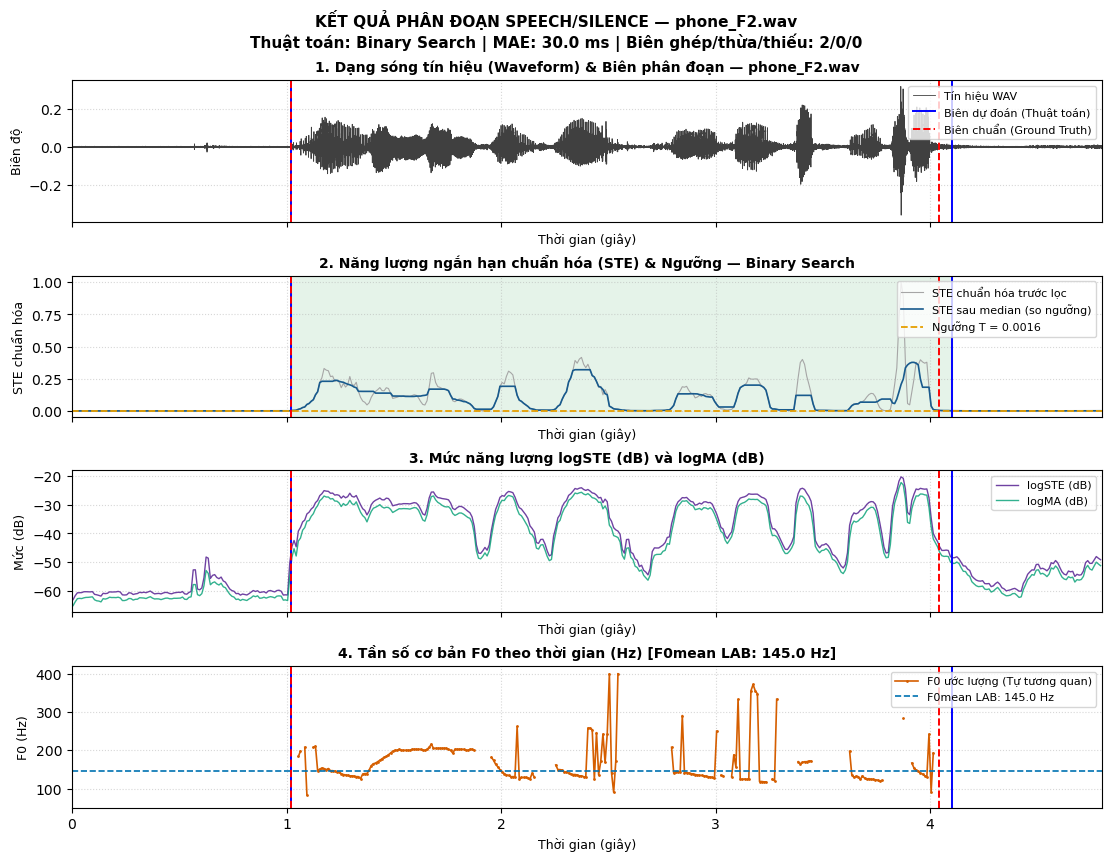

### Nhận xét phone_F2.wav

Phân khung cố định 25 ms, bước dịch 10 ms.
Cửa sổ căn giữa ô quyết định 10 ms; mép WAV chỉ dùng mẫu thật.
Hình gồm waveform, STE trước/sau median nếu có, ngưỡng/biên, logSTE/logMA và F0.
Đường xanh là biên dự đoán, đường đỏ nét đứt là biên chuẩn. Các chỉ số tính bằng ms.

### Binary Search

Ngưỡng 0.001605; MAE/RMSE 30.0/42.4 ms. Biên ghép/thừa/thiếu: 2/0/0.
- Bắt đầu Speech: chuẩn 1.02 s, dự đoán 1.02 s; lệch +0 ms.
- Kết thúc Speech: chuẩn 4.04 s, dự đoán 4.10 s; lệch +60 ms.
- Sai lệch thấy rõ (trên 30 đến 100 ms). Các mức này chỉ phục vụ bình luận, không dùng làm dung sai ghép biên.
- Biên lệch phù hợp với năng lượng tăng/giảm quanh ngưỡng và khung chồng lấn. Đây là diễn giải từ đồ thị STE, chưa chứng minh được một nguyên nhân duy nhất.

F0 ước lượng: trung vị 148.1 Hz. F0mean LAB tham chiếu: 145.0 Hz.
Khoảng trống F0 biểu thị khung không đạt điều kiện năng lượng/tương quan. Không thể khẳng định tất cả đều là vô thanh; đỉnh nhọn có thể do nhầm họa âm.


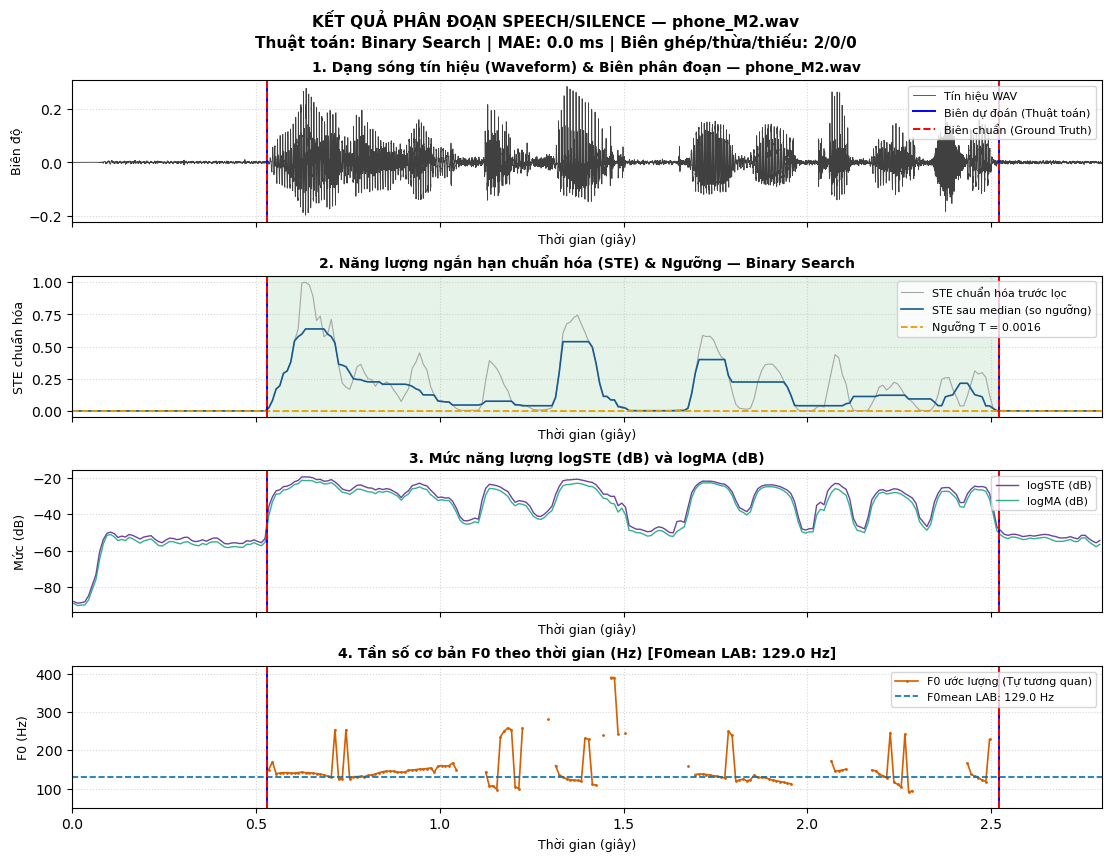

### Nhận xét phone_M2.wav

Phân khung cố định 25 ms, bước dịch 10 ms.
Cửa sổ căn giữa ô quyết định 10 ms; mép WAV chỉ dùng mẫu thật.
Hình gồm waveform, STE trước/sau median nếu có, ngưỡng/biên, logSTE/logMA và F0.
Đường xanh là biên dự đoán, đường đỏ nét đứt là biên chuẩn. Các chỉ số tính bằng ms.

### Binary Search

Ngưỡng 0.001605; MAE/RMSE 0.0/0.0 ms. Biên ghép/thừa/thiếu: 2/0/0.
- Bắt đầu Speech: chuẩn 0.53 s, dự đoán 0.53 s; lệch +0 ms.
- Kết thúc Speech: chuẩn 2.52 s, dự đoán 2.52 s; lệch +0 ms.
- Sai lệch nhỏ (tối đa 30 ms). Các mức này chỉ phục vụ bình luận, không dùng làm dung sai ghép biên.

F0 ước lượng: trung vị 139.1 Hz. F0mean LAB tham chiếu: 129.0 Hz.
Khoảng trống F0 biểu thị khung không đạt điều kiện năng lượng/tương quan. Không thể khẳng định tất cả đều là vô thanh; đỉnh nhọn có thể do nhầm họa âm.


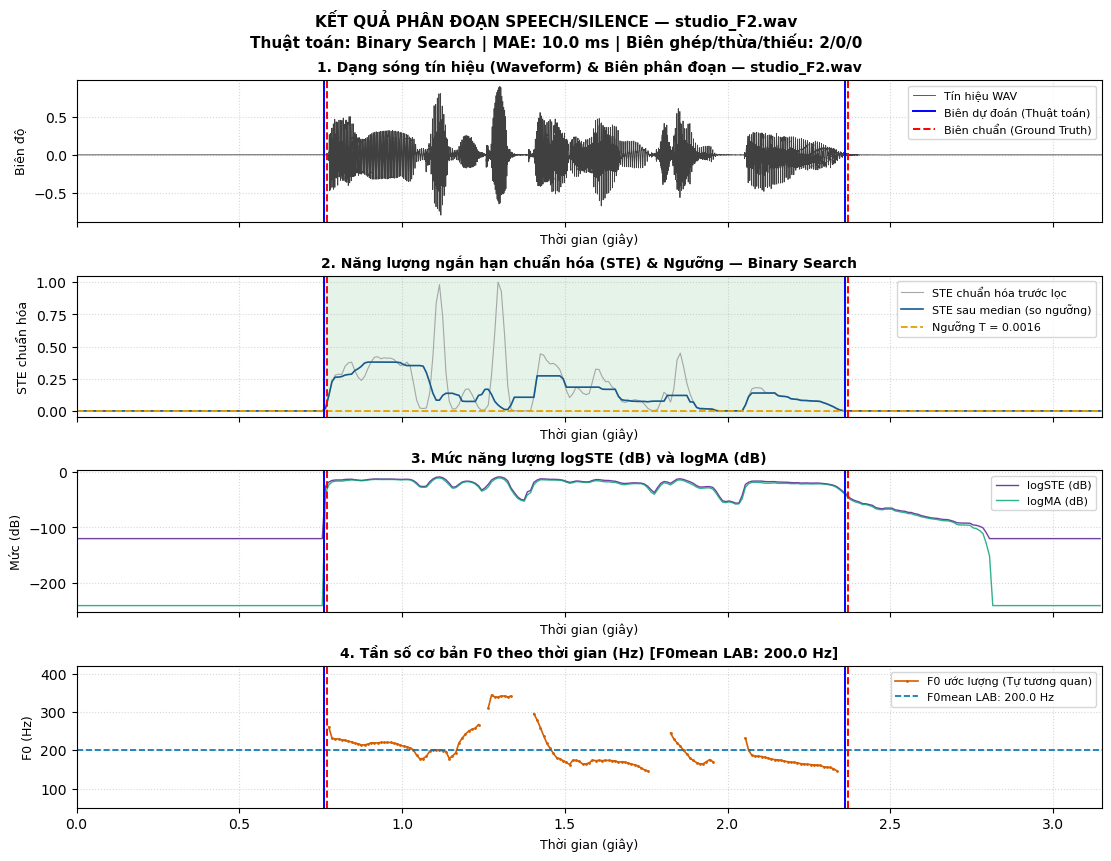

### Nhận xét studio_F2.wav

Phân khung cố định 25 ms, bước dịch 10 ms.
Cửa sổ căn giữa ô quyết định 10 ms; mép WAV chỉ dùng mẫu thật.
Hình gồm waveform, STE trước/sau median nếu có, ngưỡng/biên, logSTE/logMA và F0.
Đường xanh là biên dự đoán, đường đỏ nét đứt là biên chuẩn. Các chỉ số tính bằng ms.

### Binary Search

Ngưỡng 0.001605; MAE/RMSE 10.0/10.0 ms. Biên ghép/thừa/thiếu: 2/0/0.
- Bắt đầu Speech: chuẩn 0.77 s, dự đoán 0.76 s; lệch -10 ms.
- Kết thúc Speech: chuẩn 2.37 s, dự đoán 2.36 s; lệch -10 ms.
- Sai lệch nhỏ (tối đa 30 ms). Các mức này chỉ phục vụ bình luận, không dùng làm dung sai ghép biên.
- Biên lệch phù hợp với năng lượng tăng/giảm quanh ngưỡng và khung chồng lấn. Đây là diễn giải từ đồ thị STE, chưa chứng minh được một nguyên nhân duy nhất.

F0 ước lượng: trung vị 184.9 Hz. F0mean LAB tham chiếu: 200.0 Hz.
Khoảng trống F0 biểu thị khung không đạt điều kiện năng lượng/tương quan. Không thể khẳng định tất cả đều là vô thanh; đỉnh nhọn có thể do nhầm họa âm.


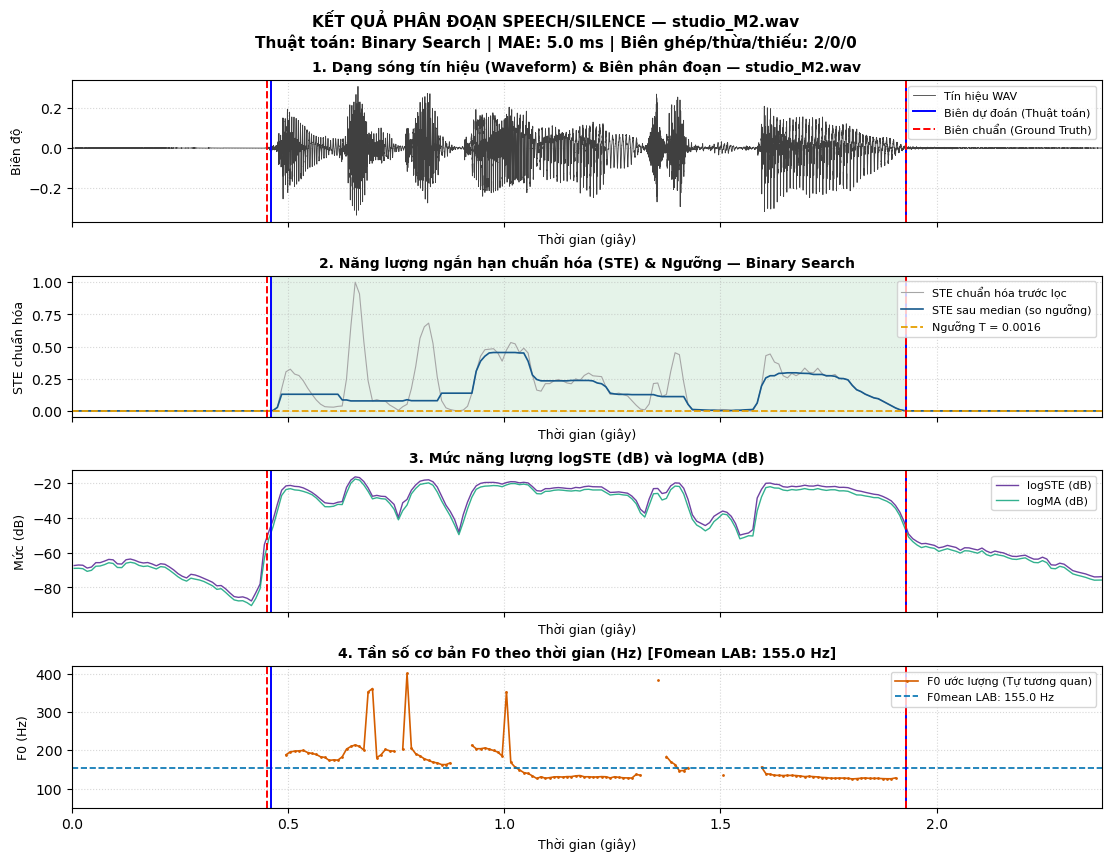

### Nhận xét studio_M2.wav

Phân khung cố định 25 ms, bước dịch 10 ms.
Cửa sổ căn giữa ô quyết định 10 ms; mép WAV chỉ dùng mẫu thật.
Hình gồm waveform, STE trước/sau median nếu có, ngưỡng/biên, logSTE/logMA và F0.
Đường xanh là biên dự đoán, đường đỏ nét đứt là biên chuẩn. Các chỉ số tính bằng ms.

### Binary Search

Ngưỡng 0.001605; MAE/RMSE 5.0/7.1 ms. Biên ghép/thừa/thiếu: 2/0/0.
- Bắt đầu Speech: chuẩn 0.45 s, dự đoán 0.46 s; lệch +10 ms.
- Kết thúc Speech: chuẩn 1.93 s, dự đoán 1.93 s; lệch +0 ms.
- Sai lệch nhỏ (tối đa 30 ms). Các mức này chỉ phục vụ bình luận, không dùng làm dung sai ghép biên.
- Biên lệch phù hợp với năng lượng tăng/giảm quanh ngưỡng và khung chồng lấn. Đây là diễn giải từ đồ thị STE, chưa chứng minh được một nguyên nhân duy nhất.

F0 ước lượng: trung vị 140.7 Hz. F0mean LAB tham chiếu: 155.0 Hz.
Khoảng trống F0 biểu thị khung không đạt điều kiện năng lượng/tương quan. Không thể khẳng định tất cả đều là vô thanh; đỉnh nhọn có thể do nhầm họa âm.


### Bảng kết quả trên toàn bộ tập test

| WAV | Ngưỡng | MAE (ms) | RMSE (ms) | Ghép/thừa/thiếu | BER |
|---|---:|---:|---:|---|---:|
| phone_F2 | 0.00160542 | 30.0 | 42.4 | 2/0/0 | 0.0169 |
| phone_M2 | 0.00160542 | 0.0 | 0.0 | 2/0/0 | 0.0000 |
| studio_F2 | 0.00160542 | 10.0 | 10.0 | 2/0/0 | 0.0064 |
| studio_M2 | 0.00160542 | 5.0 | 7.1 | 2/0/0 | 0.0034 |
| **Trung bình theo file** | | **11.2** | **14.9** | | |
| **Gộp biên** | | **11.2** | **22.1** | 8/0/0 | |

In [9]:
# Một lần gọi main xử lý đủ bốn WAV; kết quả nằm trong output của notebook.
RESULT = main()

## 10. Nhận xét nhiễu/SNR

SNR nền là ước lượng sau dự đoán. Q trong khảo sát là tỷ số công suất toàn WAV/nhiễu trắng thêm vào, không phải SNR tiếng nói sạch. Chỉ biến đổi bốn WAV test hiện có; không dùng kết quả này để chỉnh tham số.

In [10]:
def analyze_noise(records: list[Record], model: dict) -> list[dict]:
    """Nhận WAV test/mô hình đã khóa; trả BER trung bình khi cộng nhiễu, không huấn luyện lại."""
    # Khối 1: SNR nền dùng LAB để phân tích sau dự đoán, không điều chỉnh mô hình.
    lines = ["### SNR nền ước lượng từ các vùng có nhãn", "", "| WAV | SNR (dB) |", "|---|---:|"]
    for record in records:
        value = estimate_snr(record)
        lines.append(f"| {record.name} | {value:.1f} |" if value is not None else f"| {record.name} | KXĐ |")
    display(Markdown("\n".join(lines)))

    # Khối 2: Nhiễu trắng đặt theo công suất toàn WAV, dùng ba seed như chương trình gốc.
    summary = []
    for db in (30, 20, 10, 0):
        errors = []
        for record in records:
            power = float(np.mean(record.samples ** 2))
            for seed in (2026, 2027, 2028):
                rng = np.random.default_rng(seed)
                added = rng.normal(0, np.sqrt(power / (10 ** (db / 10))), len(record.samples))

                # Khối 3: Ngưỡng/hyperparameter không học lại từ kết quả khảo sát.
                f, mask, _, _ = predict_signal(record.samples + added, record.fs, model, compute_f0=False)
                errors.append(score(record, f, mask)["balanced_error"])
        summary.append({"signal_to_added_noise_db": db, "balanced_error": float(np.mean(errors))})
    table = ["### Khảo sát nhiễu bổ sung", "", "| Q (dB) | BER trung bình |", "|---:|---:|"]
    table.extend(f'| {r["signal_to_added_noise_db"]} | {r["balanced_error"]:.3f} |' for r in summary)
    display(Markdown("\n".join(table)))
    return summary


NOISE_SUMMARY = analyze_noise(RESULT["test_records"], RESULT["model"])


### SNR nền ước lượng từ các vùng có nhãn

| WAV | SNR (dB) |
|---|---:|
| phone_F2 | 24.8 |
| phone_M2 | 27.0 |
| studio_F2 | 49.3 |
| studio_M2 | 37.7 |

### Khảo sát nhiễu bổ sung

| Q (dB) | BER trung bình |
|---:|---:|
| 30 | 0.007 |
| 20 | 0.142 |
| 10 | 0.500 |
| 0 | 0.500 |

## 11. Kết luận và giới hạn

Đọc MAE/RMSE cùng số biên thừa/thiếu. Các nguyên nhân sai trong bình luận là diễn giải từ STE và hậu xử lý, không phải chứng minh nhân quả duy nhất. Dữ liệu chỉ có bốn WAV test và mỗi WAV hiện có một vùng Speech nhị phân; kết quả chưa đại diện cho mọi cuộc hội thoại hay môi trường thu âm. Triển khai theo báo cáo BT1, không có mã BT1 gốc; bộ tám W, median lặp mép và quy tắc phụ chọn nghiệm Gaussian là các mặc định đã chốt khi tái tạo.

In [11]:
# Tóm tắt từ đúng các kết quả vừa tính, không chép số liệu cố định.
p = RESULT["pooled"]
display(Markdown(f'**{METHOD_LABELS[METHOD]}**: MAE gộp **{format_metric(p["pooled_mae_ms"])} ms**, '
                 f'RMSE **{format_metric(p["pooled_rmse_ms"])} ms**; '
                 f'biên ghép/thừa/thiếu **{p["matched"]}/{p["extra"]}/{p["missed"]}**.'))

**Binary Search**: MAE gộp **11.2 ms**, RMSE **22.1 ms**; biên ghép/thừa/thiếu **8/0/0**.